# Graph Convolutional Networks (GCNs) for Graph Learning Tasks

This notebook explores the application of **Graph Convolutional Networks (GCNs)** to different graph learning tasks using **PyTorch Geometric**. The goal is to understand how GCNs can learn from graph-structured data through neighborhood aggregation and message passing.

The notebook covers three important tasks:

1. **Node Classification** on the Cora citation network  
2. **Link Prediction** on Cora  
3. **Graph Classification** on the MUTAG molecular dataset  

These experiments demonstrate how GCNs can be applied at the **node level, edge level, and graph level**

In [2]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.5 MB/s eta 0:00:00


## 1. Setup and Library Imports

In this section, the required libraries for graph neural network experiments are imported. The implementation uses **PyTorch Geometric** for graph datasets and graph convolutional layers, along with visualization and evaluation libraries such as **NetworkX**, **Matplotlib**, and **scikit-learn**.

In [3]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
import networkx as nx
import matplotlib.pyplot as plt

## 2. Node Classification using GCN on the Cora Dataset

The first task is **node classification**, where the goal is to predict the class label of each node in a graph. For this experiment, the **Cora citation network** is used, where nodes represent research papers and edges represent citation relationships.

Each node has a feature vector derived from the paper content, and the model learns to classify the papers into their corresponding research topics.

In [4]:

dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

print("Dataset Stats")
print(f"Nodes:       {data.num_nodes}")
print(f"Edges:       {data.num_edges}")
print(f"Features:    {data.num_node_features}")
print(f"Classes:     {dataset.num_classes}")

print("\nData Object")
print(f"Node features shape:  {data.x.shape}")
print(f"Edge index shape:     {data.edge_index.shape}")
print(f"Labels shape:         {data.y.shape}")

print("\Train/Val/Test Split")
print(f"Training nodes:   {data.train_mask.sum().item()}")
print(f"Validation nodes: {data.val_mask.sum().item()}")
print(f"Test nodes:       {data.test_mask.sum().item()}")


<>:15: SyntaxWarning: invalid escape sequence '\T'
<>:15: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_696/3157064830.py:15: SyntaxWarning: invalid escape sequence '\T'
  print("\Train/Val/Test Split")
Processing...


Dataset Stats
Nodes:       2708
Edges:       10556
Features:    1433
Classes:     7

Data Object
Node features shape:  torch.Size([2708, 1433])
Edge index shape:     torch.Size([2, 10556])
Labels shape:         torch.Size([2708])
\Train/Val/Test Split
Training nodes:   140
Validation nodes: 500
Test nodes:       1000


Done!


###Visualizing a Subgraph of Cora

 A smaller subgraph of Cora is extracted and displayed. This helps build intuition about the connectivity structure of the citation network.

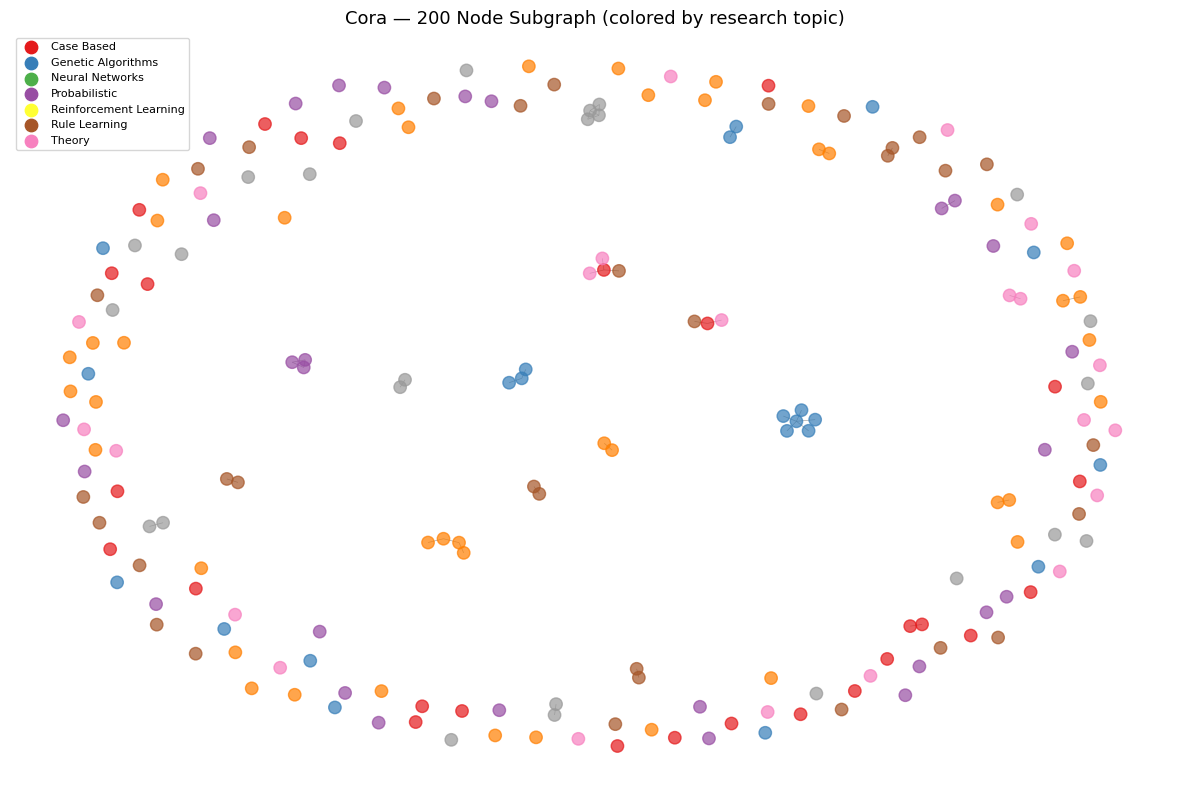

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx


subset = list(range(200))
subdata = data.subgraph(torch.tensor(subset))
G = to_networkx(subdata, to_undirected=True)


colors = data.y[subset].numpy()
class_names = ['Case Based', 'Genetic Algorithms', 'Neural Networks',
               'Probabilistic', 'Reinforcement Learning', 'Rule Learning', 'Theory']

# Plot
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(
    G,
    pos=pos,
    node_color=colors,
    cmap=plt.cm.Set1,
    node_size=80,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.5
)

handles = [plt.scatter([], [], c=[plt.cm.Set1(i/7)], s=80, label=class_names[i]) for i in range(7)]
plt.legend(handles=handles, loc='upper left', fontsize=8)
plt.title("Cora — 200 Node Subgraph (colored by research topic)", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

###Defining the GCN Model

A two-layer **Graph Convolutional Network (GCN)** is defined for node classification. Each graph convolution layer updates a node representation by aggregating information from its neighboring nodes.



In [6]:
from torch_geometric.nn import GCNConv
import torch.nn as nn

class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(1433, 64)
        self.conv2 = GCNConv(64, 7)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)


        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

    def get_embeddings(self, x, edge_index):

        return self.conv1(x, edge_index)


model = GCN()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")


GCN(
  (conv1): GCNConv(1433, 64)
  (conv2): GCNConv(64, 7)
)

Total parameters: 92231


Training loop is defined

In [7]:

model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
    val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).sum().item()   / data.val_mask.sum().item()
    test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).sum().item()  / data.test_mask.sum().item()

    return train_acc, val_acc, test_acc

train_losses = []
test_accuracies = []

for epoch in range(200):
    loss = train()
    train_acc, val_acc, test_acc = test()

    train_losses.append(loss)
    test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

print(f"\n Final Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

Epoch   0 | Loss: 1.9621 | Train: 0.8500 | Val: 0.5540 | Test: 0.6420
Epoch  20 | Loss: 0.0182 | Train: 1.0000 | Val: 0.7680 | Test: 0.7870
Epoch  40 | Loss: 0.0061 | Train: 1.0000 | Val: 0.7660 | Test: 0.7920
Epoch  60 | Loss: 0.0126 | Train: 1.0000 | Val: 0.7720 | Test: 0.7930
Epoch  80 | Loss: 0.0145 | Train: 1.0000 | Val: 0.7700 | Test: 0.7940
Epoch 100 | Loss: 0.0114 | Train: 1.0000 | Val: 0.7680 | Test: 0.7930
Epoch 120 | Loss: 0.0111 | Train: 1.0000 | Val: 0.7660 | Test: 0.7960
Epoch 140 | Loss: 0.0107 | Train: 1.0000 | Val: 0.7780 | Test: 0.7980
Epoch 160 | Loss: 0.0100 | Train: 1.0000 | Val: 0.7780 | Test: 0.8000
Epoch 180 | Loss: 0.0096 | Train: 1.0000 | Val: 0.7720 | Test: 0.7990

 Final Test Accuracy: 0.8190 (81.9%)


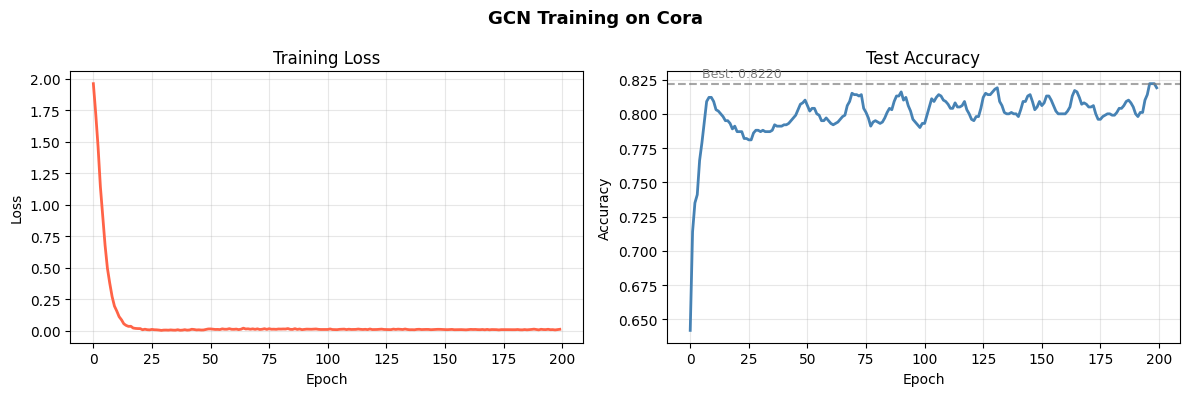

In [8]:
plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(train_losses, color='tomato', linewidth=2)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(test_accuracies, color='steelblue', linewidth=2)
plt.axhline(y=max(test_accuracies), color='gray', linestyle='--', alpha=0.7)
plt.text(5, max(test_accuracies)+0.005, f'Best: {max(test_accuracies):.4f}', fontsize=9, color='gray')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

plt.suptitle('GCN Training on Cora', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

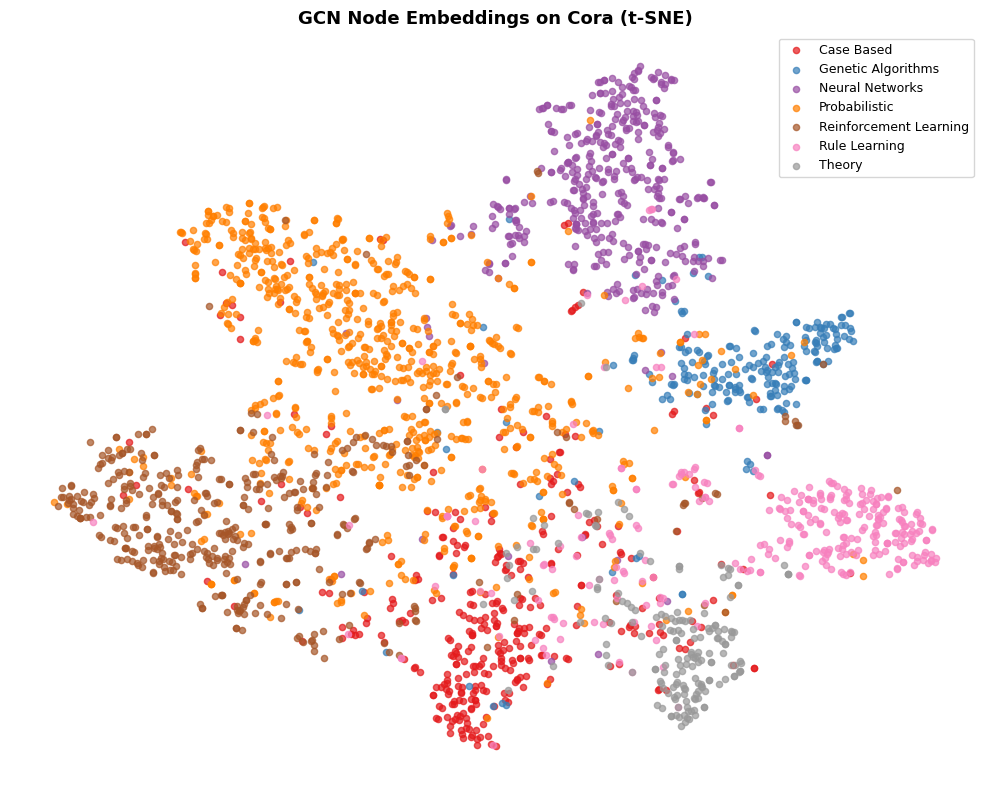

In [9]:
from sklearn.manifold import TSNE
import numpy as np


model.eval()
with torch.no_grad():
    embeddings = model.get_embeddings(data.x, data.edge_index)
    embeddings = F.relu(embeddings)
    embeddings = embeddings.numpy()


tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)


class_names = ['Case Based', 'Genetic Algorithms', 'Neural Networks',
               'Probabilistic', 'Reinforcement Learning', 'Rule Learning', 'Theory']
labels = data.y.numpy()
colors = plt.cm.Set1(np.linspace(0, 1, 7))

plt.figure(figsize=(10, 8))
for i in range(7):
    mask = labels == i
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        label=class_names[i],
        alpha=0.7,
        s=20
    )

plt.title('GCN Node Embeddings on Cora (t-SNE)', fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.axis('off')
plt.tight_layout()
plt.show()

### Message Passing

GCNs work by aggregating information from neighboring nodes.

Node 0 has 3 neighbors: [633, 1862, 2582]...

 Node 0 own features
[0. 0. 0. 0. 0. 0.]

Neighbor features
  Neighbor 633: [0. 0. 0. 0. 0. 0.]
  Neighbor 1862: [0. 0. 0. 0. 0. 0.]
  Neighbor 2582: [0. 0. 0. 0. 0. 0.]

Aggregated mean of all neighbors
[0. 0. 0. 0. 0. 0.]


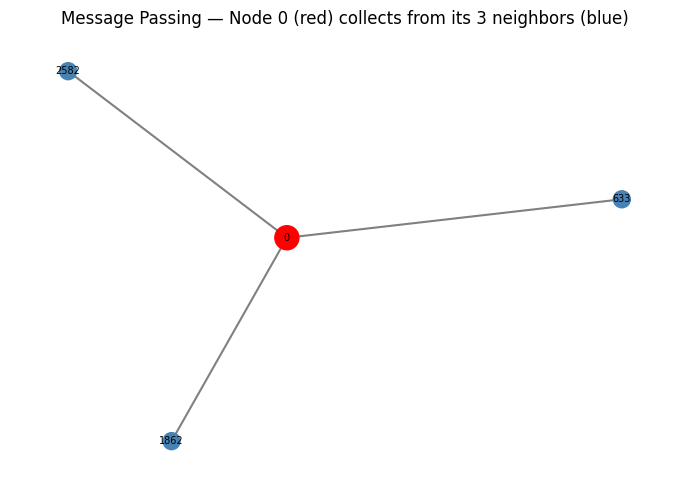

In [10]:

node_id = 0

edge_index = data.edge_index
neighbors = edge_index[1][edge_index[0] == node_id].tolist()
print(f"Node {node_id} has {len(neighbors)} neighbors: {neighbors[:8]}...")


print(f"\n Node {node_id} own features")
print(data.x[node_id][:6].numpy())


print(f"\nNeighbor features")
for n in neighbors[:3]:
    print(f"  Neighbor {n}: {data.x[n][:6].numpy()}")

neighbor_features = data.x[neighbors]
aggregated = neighbor_features.mean(dim=0)
print(f"\nAggregated mean of all neighbors")
print(aggregated[:6].detach().numpy())

G_sub = nx.Graph()
G_sub.add_node(node_id)
for n in neighbors:
    G_sub.add_edge(node_id, n)

plt.figure(figsize=(7, 5))
pos = nx.spring_layout(G_sub, seed=42)
nx.draw_networkx(G_sub, pos=pos,
    node_color=['red' if n == node_id else 'steelblue' for n in G_sub.nodes()],
    node_size=[300 if n == node_id else 150 for n in G_sub.nodes()],
    with_labels=True, font_size=7,
    edge_color='gray', width=1.5)
plt.title(f"Message Passing — Node {node_id} (red) collects from its {len(neighbors)} neighbors (blue)")
plt.axis('off')
plt.tight_layout()
plt.show()


In [12]:
import torch
import torch.nn.functional as F
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
import matplotlib.pyplot as plt

In [13]:
link_split_transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=True,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0
)

link_train_data, link_val_data, link_test_data = link_split_transform(dataset[0])

print("Link Prediction Split Summary")
print(f"Train edges for message passing: {link_train_data.edge_index.shape[1]}")
print(f"Train edge labels: {link_train_data.edge_label.shape[0]}")
print(f"Validation edge labels: {link_val_data.edge_label.shape[0]}")
print(f"Test edge labels: {link_test_data.edge_label.shape[0]}")

Link Prediction Split Summary
Train edges for message passing: 8448
Train edge labels: 8448
Validation edge labels: 1054
Test edge labels: 1054


## 3. Link Prediction using GCN on Cora

In **link prediction**, where the goal is to determine whether an edge should exist between two nodes. In the context of the Cora citation graph, this means predicting whether two papers are likely to be connected.
.

In [14]:
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, embedding_dim, dropout_rate=0.5):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, embedding_dim)
        self.dropout_rate = dropout_rate

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, node_embeddings, edge_label_index):
        source_nodes = edge_label_index[0]
        destination_nodes = edge_label_index[1]

        source_embeddings = node_embeddings[source_nodes]
        destination_embeddings = node_embeddings[destination_nodes]

        edge_scores = (source_embeddings * destination_embeddings).sum(dim=1)
        return edge_scores

    def forward(self, x, edge_index, edge_label_index):
        node_embeddings = self.encode(x, edge_index)
        edge_scores = self.decode(node_embeddings, edge_label_index)
        return edge_scores

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

link_train_data = link_train_data.to(device)
link_val_data = link_val_data.to(device)
link_test_data = link_test_data.to(device)

link_model = GCNLinkPredictor(
    input_dim=dataset.num_node_features,
    hidden_dim=64,
    embedding_dim=32,
    dropout_rate=0.5
).to(device)

link_optimizer = torch.optim.Adam(link_model.parameters(), lr=0.01, weight_decay=5e-4)
link_criterion = torch.nn.BCEWithLogitsLoss()

In [18]:
def evaluate_link_predictor(model, graph_data):
    model.eval()
    with torch.no_grad():
        edge_logits = model(
            graph_data.x,
            graph_data.edge_index,
            graph_data.edge_label_index
        )

        edge_probabilities = torch.sigmoid(edge_logits).cpu().numpy()
        true_edge_labels = graph_data.edge_label.cpu().numpy()

        loss = link_criterion(edge_logits, graph_data.edge_label.float()).item()
        predicted_edge_labels = (edge_probabilities >= 0.5).astype(int)

        accuracy = accuracy_score(true_edge_labels, predicted_edge_labels)
        auc = roc_auc_score(true_edge_labels, edge_probabilities)

    return loss, accuracy, auc, true_edge_labels, edge_probabilities

In [21]:
num_link_epochs = 300

link_train_losses = []
link_val_losses = []
link_val_accuracies = []
link_val_aucs = []

best_link_val_auc = 0
best_link_model_state = None
best_link_epoch = 0

for epoch in range(num_link_epochs):
    link_model.train()
    link_optimizer.zero_grad()

    train_edge_logits = link_model(
        link_train_data.x,
        link_train_data.edge_index,
        link_train_data.edge_label_index
    )

    train_loss = link_criterion(
        train_edge_logits,
        link_train_data.edge_label.float()
    )

    train_loss.backward()
    link_optimizer.step()

    train_loss_value, train_acc_value, train_auc_value, _, _ = evaluate_link_predictor(link_model, link_train_data)
    val_loss_value, val_acc_value, val_auc_value, _, _ = evaluate_link_predictor(link_model, link_val_data)

    link_train_losses.append(train_loss_value)
    link_val_losses.append(val_loss_value)
    link_val_accuracies.append(val_acc_value)
    link_val_aucs.append(val_auc_value)

    if val_auc_value > best_link_val_auc:
        best_link_val_auc = val_auc_value
        best_link_model_state = link_model.state_dict()
        best_link_epoch = epoch + 1

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss_value:.4f} | "
            f"Val Loss: {val_loss_value:.4f} | "
            f"Val Accuracy: {val_acc_value:.4f} | "
            f"Val AUC: {val_auc_value:.4f}"
        )

Epoch 020 | Train Loss: 0.0351 | Val Loss: 1.3258 | Val Accuracy: 0.7021 | Val AUC: 0.7602
Epoch 040 | Train Loss: 0.0333 | Val Loss: 1.4001 | Val Accuracy: 0.6926 | Val AUC: 0.7631
Epoch 060 | Train Loss: 0.0354 | Val Loss: 1.3103 | Val Accuracy: 0.6983 | Val AUC: 0.7639
Epoch 080 | Train Loss: 0.0327 | Val Loss: 1.3447 | Val Accuracy: 0.6973 | Val AUC: 0.7673
Epoch 100 | Train Loss: 0.0320 | Val Loss: 1.3686 | Val Accuracy: 0.7002 | Val AUC: 0.7658
Epoch 120 | Train Loss: 0.0337 | Val Loss: 1.3493 | Val Accuracy: 0.6964 | Val AUC: 0.7634
Epoch 140 | Train Loss: 0.0327 | Val Loss: 1.3553 | Val Accuracy: 0.7097 | Val AUC: 0.7676
Epoch 160 | Train Loss: 0.0331 | Val Loss: 1.3515 | Val Accuracy: 0.6973 | Val AUC: 0.7675
Epoch 180 | Train Loss: 0.0315 | Val Loss: 1.4072 | Val Accuracy: 0.7002 | Val AUC: 0.7667
Epoch 200 | Train Loss: 0.0341 | Val Loss: 1.3710 | Val Accuracy: 0.6907 | Val AUC: 0.7625
Epoch 220 | Train Loss: 0.0336 | Val Loss: 1.4559 | Val Accuracy: 0.7021 | Val AUC: 0.7652

In [22]:
link_model.load_state_dict(best_link_model_state)

final_train_loss, final_train_acc, final_train_auc, _, _ = evaluate_link_predictor(link_model, link_train_data)
final_val_loss, final_val_acc, final_val_auc, _, _ = evaluate_link_predictor(link_model, link_val_data)
final_test_loss, final_test_acc, final_test_auc, test_edge_labels, test_edge_probabilities = evaluate_link_predictor(link_model, link_test_data)

print("\nBest Link Prediction Model Summary")
print(f"Best Epoch: {best_link_epoch}")
print(f"Best Validation AUC: {best_link_val_auc:.4f}")
print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}")
print(f"Final Train AUC: {final_train_auc:.4f}")
print(f"Final Validation AUC: {final_val_auc:.4f}")
print(f"Final Test AUC: {final_test_auc:.4f}")


Best Link Prediction Model Summary
Best Epoch: 104
Best Validation AUC: 0.7713
Final Train Accuracy: 0.9964
Final Validation Accuracy: 0.6917
Final Test Accuracy: 0.7220
Final Train AUC: 1.0000
Final Validation AUC: 0.7601
Final Test AUC: 0.8016


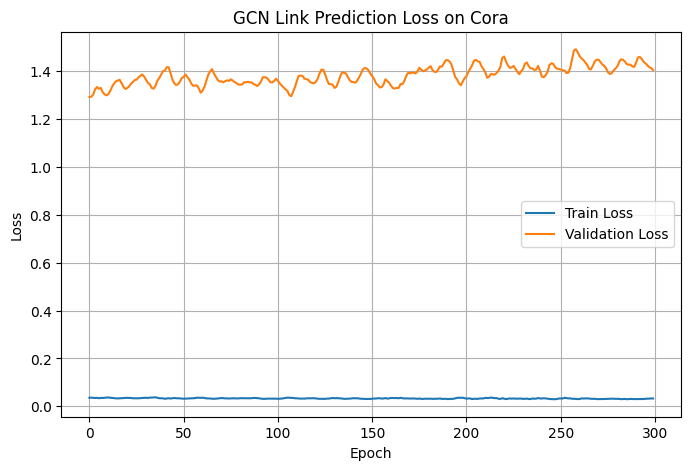

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(link_train_losses, label="Train Loss")
plt.plot(link_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GCN Link Prediction Loss on Cora")
plt.legend()
plt.grid(True)
plt.show()

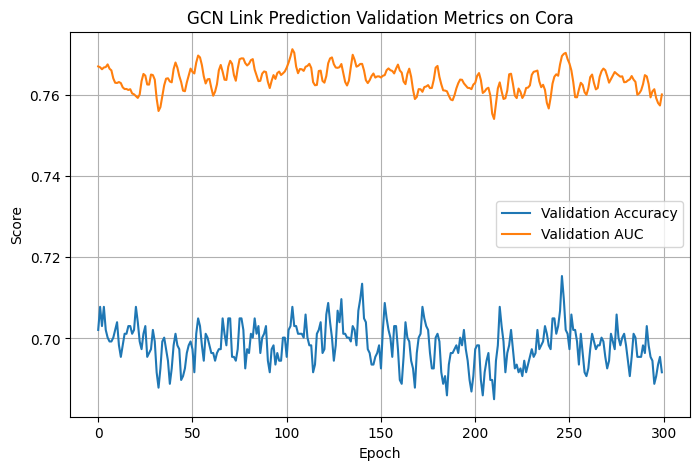

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(link_val_accuracies, label="Validation Accuracy")
plt.plot(link_val_aucs, label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("GCN Link Prediction Validation Metrics on Cora")
plt.legend()
plt.grid(True)
plt.show()

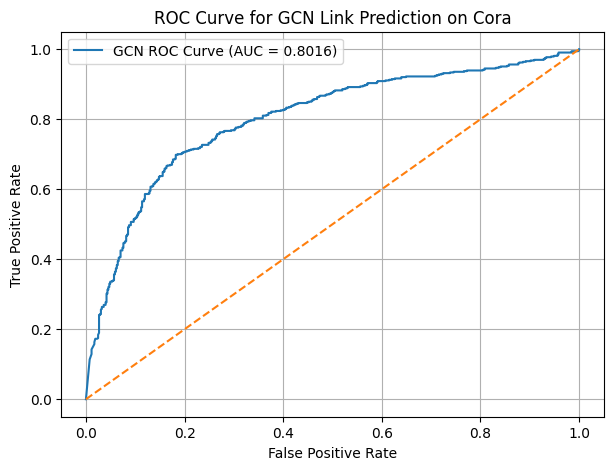

In [25]:
false_positive_rate, true_positive_rate, _ = roc_curve(test_edge_labels, test_edge_probabilities)

plt.figure(figsize=(7, 5))
plt.plot(false_positive_rate, true_positive_rate, label=f"GCN ROC Curve (AUC = {final_test_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for GCN Link Prediction on Cora")
plt.legend()
plt.grid(True)
plt.show()

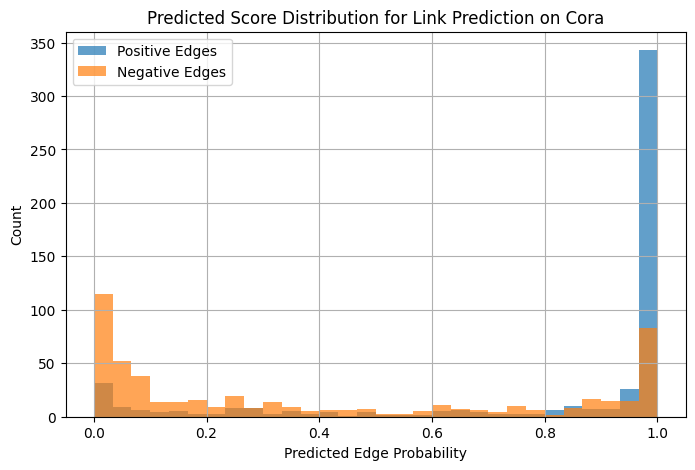

In [26]:
positive_edge_scores = test_edge_probabilities[test_edge_labels == 1]
negative_edge_scores = test_edge_probabilities[test_edge_labels == 0]

plt.figure(figsize=(8, 5))
plt.hist(positive_edge_scores, bins=30, alpha=0.7, label="Positive Edges")
plt.hist(negative_edge_scores, bins=30, alpha=0.7, label="Negative Edges")
plt.xlabel("Predicted Edge Probability")
plt.ylabel("Count")
plt.title("Predicted Score Distribution for Link Prediction on Cora")
plt.legend()
plt.grid(True)
plt.show()

## 4. Graph Classification using GCN on MUTAG

In **graph classification**,  the goal is to assign a label to an entire graph rather than to individual nodes or edges. For this, the **MUTAG** dataset is used, where each graph represents a molecule.

A GCN is used to learn node embeddings, which are then aggregated into a single graph-level representation using a pooling operation. This graph embedding is finally used for classification.

In [34]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

In [29]:
mutag_dataset = TUDataset(root="data/TUDataset", name="MUTAG")

print("MUTAG Dataset Summary")
print(f"Number of graphs: {len(mutag_dataset)}")
print(f"Number of classes: {mutag_dataset.num_classes}")
print(f"Number of node features: {mutag_dataset.num_node_features}")

MUTAG Dataset Summary
Number of graphs: 188
Number of classes: 2
Number of node features: 7


Processing...
Done!


In [30]:
sample_graph = mutag_dataset[0]

print("\nSample Graph")
print(f"Number of nodes: {sample_graph.num_nodes}")
print(f"Number of edges: {sample_graph.edge_index.shape[1]}")
print(f"Graph label: {sample_graph.y.item()}")
print(f"Node feature shape: {sample_graph.x.shape}")


Sample Graph
Number of nodes: 17
Number of edges: 38
Graph label: 1
Node feature shape: torch.Size([17, 7])


In [35]:
graph_labels = [graph.y.item() for graph in mutag_dataset]
graph_indices = list(range(len(mutag_dataset)))

train_indices, test_indices = train_test_split(
    graph_indices,
    test_size=0.2,
    random_state=42,
    stratify=graph_labels
)

train_graphs = [mutag_dataset[index] for index in train_indices]
test_graphs = [mutag_dataset[index] for index in test_indices]

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

print("\nGraph Split Summary")
print(f"Training graph: {len(train_graphs)}")
print(f"Test graph: {len(test_graphs)}")


Graph Split Summary
Training graph: 150
Test graph: 38


In [36]:
class GCNGraphClassifier(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.5):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout_rate = dropout_rate
        self.classifier = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        graph_embeddings = global_mean_pool(x, batch)
        graph_embeddings = F.dropout(graph_embeddings, p=self.dropout_rate, training=self.training)

        output_logits = self.classifier(graph_embeddings)
        return output_logits

    def get_graph_embeddings(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        graph_embeddings = global_mean_pool(x, batch)
        return graph_embeddings

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

graph_model = GCNGraphClassifier(
    input_dim=mutag_dataset.num_node_features,
    hidden_dim=64,
    output_dim=mutag_dataset.num_classes,
    dropout_rate=0.5
).to(device)

graph_optimizer = torch.optim.Adam(graph_model.parameters(), lr=0.01, weight_decay=5e-4)
graph_criterion = torch.nn.CrossEntropyLoss()

In [38]:
def train_graph_classifier(model, data_loader):
    model.train()
    total_loss = 0
    total_correct = 0
    total_graphs = 0

    for batch_data in data_loader:
        batch_data = batch_data.to(device)

        graph_optimizer.zero_grad()
        output_logits = model(batch_data.x, batch_data.edge_index, batch_data.batch)
        loss = graph_criterion(output_logits, batch_data.y)

        loss.backward()
        graph_optimizer.step()

        total_loss += loss.item() * batch_data.num_graphs
        predicted_labels = output_logits.argmax(dim=1)
        total_correct += (predicted_labels == batch_data.y).sum().item()
        total_graphs += batch_data.num_graphs

    average_loss = total_loss / total_graphs
    average_accuracy = total_correct / total_graphs
    return average_loss, average_accuracy


def evaluate_graph_classifier(model, data_loader):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_graphs = 0

    all_true_labels = []
    all_predicted_labels = []

    with torch.no_grad():
        for batch_data in data_loader:
            batch_data = batch_data.to(device)

            output_logits = model(batch_data.x, batch_data.edge_index, batch_data.batch)
            loss = graph_criterion(output_logits, batch_data.y)

            total_loss += loss.item() * batch_data.num_graphs
            predicted_labels = output_logits.argmax(dim=1)

            total_correct += (predicted_labels == batch_data.y).sum().item()
            total_graphs += batch_data.num_graphs

            all_true_labels.extend(batch_data.y.cpu().numpy())
            all_predicted_labels.extend(predicted_labels.cpu().numpy())

    average_loss = total_loss / total_graphs
    average_accuracy = total_correct / total_graphs
    return average_loss, average_accuracy, all_true_labels, all_predicted_labels

In [39]:
num_graph_epochs = 100

graph_train_losses = []
graph_test_losses = []
graph_train_accuracies = []
graph_test_accuracies = []

best_graph_test_accuracy = 0
best_graph_model_state = None
best_graph_epoch = 0

for epoch in range(num_graph_epochs):
    train_loss_value, train_accuracy_value = train_graph_classifier(graph_model, train_loader)
    test_loss_value, test_accuracy_value, _, _ = evaluate_graph_classifier(graph_model, test_loader)

    graph_train_losses.append(train_loss_value)
    graph_test_losses.append(test_loss_value)
    graph_train_accuracies.append(train_accuracy_value)
    graph_test_accuracies.append(test_accuracy_value)

    if test_accuracy_value > best_graph_test_accuracy:
        best_graph_test_accuracy = test_accuracy_value
        best_graph_model_state = deepcopy(graph_model.state_dict())
        best_graph_epoch = epoch + 1

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss_value:.4f} | "
            f"Test Loss: {test_loss_value:.4f} | "
            f"Train Accuracy: {train_accuracy_value:.4f} | "
            f"Test Accuracy: {test_accuracy_value:.4f}"
        )

Epoch 010 | Train Loss: 0.5405 | Test Loss: 0.6176 | Train Accuracy: 0.7200 | Test Accuracy: 0.6316
Epoch 020 | Train Loss: 0.5022 | Test Loss: 0.6025 | Train Accuracy: 0.7733 | Test Accuracy: 0.6579
Epoch 030 | Train Loss: 0.4741 | Test Loss: 0.6232 | Train Accuracy: 0.7600 | Test Accuracy: 0.6842
Epoch 040 | Train Loss: 0.4609 | Test Loss: 0.6121 | Train Accuracy: 0.8000 | Test Accuracy: 0.6579
Epoch 050 | Train Loss: 0.4717 | Test Loss: 0.6318 | Train Accuracy: 0.8000 | Test Accuracy: 0.6053
Epoch 060 | Train Loss: 0.4772 | Test Loss: 0.6157 | Train Accuracy: 0.7867 | Test Accuracy: 0.6842
Epoch 070 | Train Loss: 0.4805 | Test Loss: 0.6206 | Train Accuracy: 0.7867 | Test Accuracy: 0.6842
Epoch 080 | Train Loss: 0.4935 | Test Loss: 0.6458 | Train Accuracy: 0.7733 | Test Accuracy: 0.6316
Epoch 090 | Train Loss: 0.4639 | Test Loss: 0.6237 | Train Accuracy: 0.7667 | Test Accuracy: 0.6316
Epoch 100 | Train Loss: 0.4736 | Test Loss: 0.6527 | Train Accuracy: 0.7733 | Test Accuracy: 0.6053


In [40]:
 graph_model.load_state_dict(best_graph_model_state)

final_graph_train_loss, final_graph_train_accuracy, _, _ = evaluate_graph_classifier(graph_model, train_loader)
final_graph_test_loss, final_graph_test_accuracy, final_true_graph_labels, final_predicted_graph_labels = evaluate_graph_classifier(graph_model, test_loader)

print("\nBest GCN Graph Classification Summary")
print(f"Best Epoch: {best_graph_epoch}")
print(f"Final Train Accuracy: {final_graph_train_accuracy:.4f}")
print(f"Final Test Accuracy: {final_graph_test_accuracy:.4f}")


Best GCN Graph Classification Summary
Best Epoch: 36
Final Train Accuracy: 0.7867
Final Test Accuracy: 0.7105


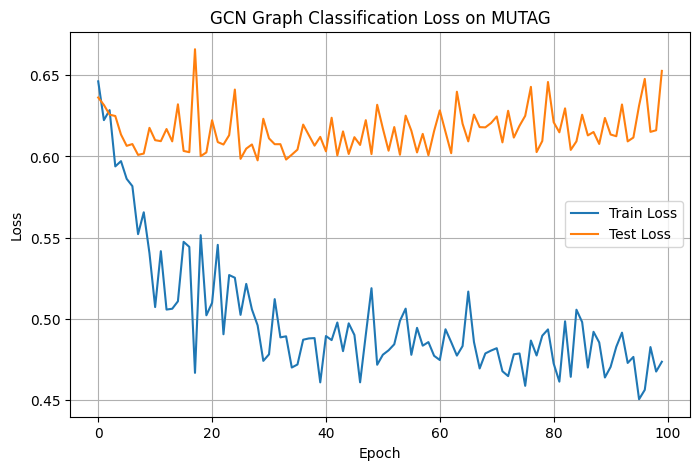

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(graph_train_losses, label="Train Loss")
plt.plot(graph_test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GCN Graph Classification Loss on MUTAG")
plt.legend()
plt.grid(True)
plt.show()

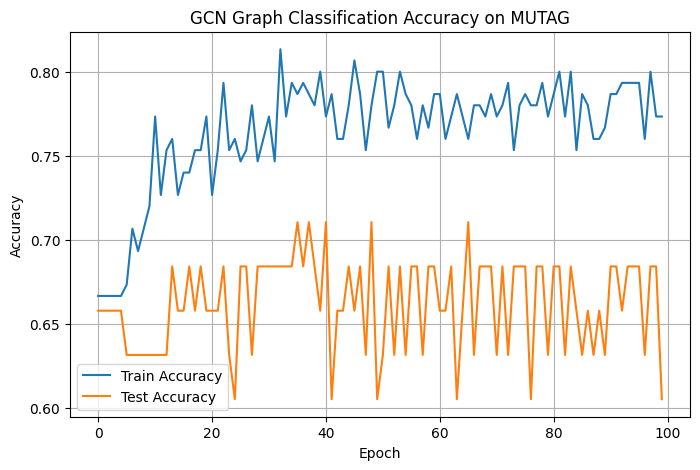

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(graph_train_accuracies, label="Train Accuracy")
plt.plot(graph_test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GCN Graph Classification Accuracy on MUTAG")
plt.legend()
plt.grid(True)
plt.show()

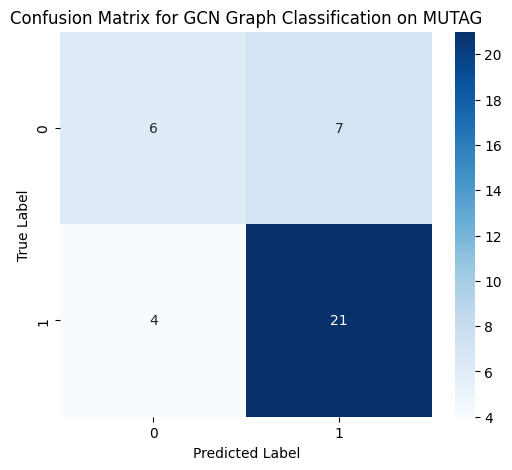

Classification Report:

              precision    recall  f1-score   support

           0     0.6000    0.4615    0.5217        13
           1     0.7500    0.8400    0.7925        25

    accuracy                         0.7105        38
   macro avg     0.6750    0.6508    0.6571        38
weighted avg     0.6987    0.7105    0.6998        38



In [43]:
graph_conf_matrix = confusion_matrix(final_true_graph_labels, final_predicted_graph_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(graph_conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for GCN Graph Classification on MUTAG")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Classification Report:\n")
print(classification_report(final_true_graph_labels, final_predicted_graph_labels, digits=4))

References:

1) https://networkx.org/documentation/stable/tutorial.html

2) https://networkx.org/documentation/stable/reference/drawing.html

3) https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

4) https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html

5) https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html

6) https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.Planetoid.html

7) https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html

8) https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.transforms.RandomLinkSplit.html

9) https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.TUDataset.html


